# BTC Up/Down 5-Minute Market — Simple Backtest

**Event slug:** `btc-updown-5m-1776732000`  
**Title:** Bitcoin Up or Down — April 20, 8:40PM–8:45PM ET  
**Outcome:** Will BTC close higher over that 5-minute window?  
**Resolution:** Down won (BTC fell) → `Up` settled at **0.0**

**Strategy: Fade the Extremes (Mean Reversion)**  
Buy the `Up` outcome when the market is too pessimistic; sell when it is too optimistic.

| Signal | Action |
|---|---|
| `close < BUY_THRESHOLD` | Buy `TRADE_SIZE` shares |
| `close > SELL_THRESHOLD` and long | Sell entire position |
| Otherwise | Hold |

---

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

In [3]:
from datetime import datetime, timezone, timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from polymarket_data import PolymarketData
from backtester.datamodel import Listing, Order, TradingState
from backtester.engine import BacktestEngine
from backtester.fill_model import NextBarOpen

## 1. Resolve event metadata

`get_event()` hits `/events?slug=...` on the Gamma API and returns one
`MarketInfo` per market inside the event.  This event has a single market.

In [4]:
EVENT_SLUG = "btc-updown-5m-1776732000"

pm = PolymarketData()
markets = pm.get_event(EVENT_SLUG)

# This event contains one market; pick it.
market = markets[0]
SLUG = market.slug

print(f"Event markets : {len(markets)}")
print(f"Market slug   : {SLUG}")
print(f"Question      : {market.question}")
print(f"Outcomes      : {market.outcomes}")
print(f"Token IDs     : {[tid[:12] + '...' for tid in market.token_ids]}")

Event markets : 1
Market slug   : btc-updown-5m-1776732000
Question      : Bitcoin Up or Down - April 20, 8:40PM-8:45PM ET
Outcomes      : ['Up', 'Down']
Token IDs     : ['931290236609...', '408561003787...']


## 2. Fetch 5-minute OHLCV bars

The market traded from April 20 until it closed at **April 21 00:45 UTC**.  
We fetch the full 24-hour trading window at 5-minute resolution for the `Up` outcome (index 0).

In [14]:
OUTCOME = market.outcomes[0]   # "Up"

START = datetime(2026, 4, 20, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 21, 1, 0, tzinfo=timezone.utc)   # a little past close

print(f"Fetching '{OUTCOME}' bars: {START} → {END}")

bars = pm.price_series(
    slug=SLUG,
    start_time=START,
    end_time=END,
    freq="5s",
    outcome_index=0,
    fill_gaps=True,
    backend="pandas",
)

active = bars[bars["trade_count"] > 0]
print(f"{len(bars)} bars total  |  {len(active)} with trades  |  "
      f"price range [{active['close'].min():.3f}, {active['close'].max():.3f}]")
active.head(10)

Fetching 'Up' bars: 2026-04-20 00:00:00+00:00 → 2026-04-21 01:00:00+00:00
18000 bars total  |  122 with trades  |  price range [0.010, 0.740]


,open,high,low,close,vwap,volume,trade_count
timestamp,,,,,,,
2026-04-21 00:15:10+00:00,0.51,0.51,0.51,0.51,0.510000,1.960783,1
2026-04-21 00:18:50+00:00,0.51,0.51,0.51,0.51,0.510000,1.960783,1
2026-04-21 00:22:20+00:00,0.51,0.51,0.51,0.51,0.510000,9.803920,1
2026-04-21 00:22:30+00:00,0.51,0.51,0.51,0.51,0.510000,1.960783,1
2026-04-21 00:22:45+00:00,0.51,0.51,0.51,0.51,0.510000,25.000000,1
2026-04-21 00:29:35+00:00,0.51,0.51,0.50,0.50,0.500374,103.882351,3
2026-04-21 00:29:40+00:00,0.51,0.51,0.50,0.50,0.503953,19.644702,8
2026-04-21 00:30:00+00:00,0.50,0.50,0.50,0.50,0.500000,100.000000,3
2026-04-21 00:30:30+00:00,0.51,0.51,0.51,0.51,0.510000,1.960783,1


## 3. Visualise the price series

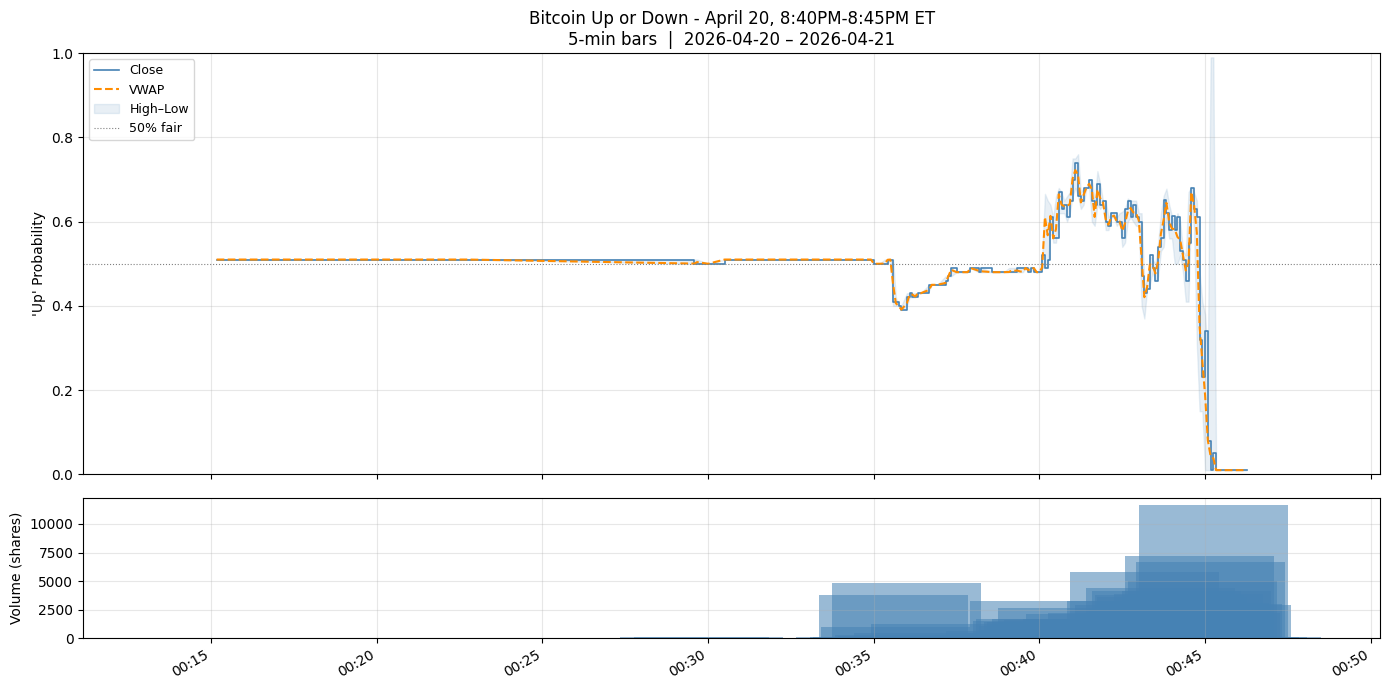

In [15]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax1.step(active.index, active["close"], where="post",
         color="steelblue", linewidth=1.2, label="Close")
ax1.plot(active.index, active["vwap"],
         color="darkorange", linewidth=1.5, linestyle="--", label="VWAP")
ax1.fill_between(active.index, active["low"], active["high"],
                 alpha=0.12, color="steelblue", label="High–Low")
ax1.axhline(0.5, color="gray", linewidth=0.8, linestyle=":", label="50% fair")
ax1.set_ylabel(f"'{OUTCOME}' Probability")
ax1.set_title(f"{market.question}\n5-min bars  |  {START.date()} – {END.date()}")
ax1.legend(loc="upper left", fontsize=9)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

ax2.bar(active.index, active["volume"],
        width=pd.Timedelta("4.5min"), color="steelblue", alpha=0.55)
ax2.set_ylabel("Volume (shares)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 4. Strategy: Fade the Extremes

Binary prediction markets tend to overreact, then partially revert.  
This strategy bets on that reversion by trading against extreme probability readings.

In [16]:
BUY_THRESHOLD  = 0.35   # buy when Up looks too cheap
SELL_THRESHOLD = 0.65   # sell when Up looks too expensive
TRADE_SIZE     = 100    # shares per buy order


class FadeExtremesTrader:
    def run(self, state: TradingState):
        symbol   = next(iter(state.listings))
        bar      = state.bars[symbol]
        position = state.position.get(symbol, 0.0)
        orders   = []

        if bar.trade_count == 0 or bar.close != bar.close:  # skip empty / NaN bars
            return {symbol: orders}, ""

        price = bar.close

        if price < BUY_THRESHOLD and position <= 0:
            # Use price=1.0 (market order) so the fill isn't rejected when
            # the next bar opens above our close-based limit.
            orders.append(Order(symbol=symbol, price=1.0, quantity=TRADE_SIZE))
        elif price > SELL_THRESHOLD and position > 0:
            orders.append(Order(symbol=symbol, price=0.0, quantity=-position))

        return {symbol: orders}, ""


print(f"buy < {BUY_THRESHOLD}  |  sell > {SELL_THRESHOLD}  |  size = {TRADE_SIZE} shares")

buy < 0.35  |  sell > 0.65  |  size = 100 shares


## 5. Run the backtest

The market is resolved: **Down won**, so the `Up` outcome settled at **0.0**.

In [17]:
# Down won → Up settled at 0.0
RESOLUTION = 0.0

listing = Listing(
    symbol=SLUG,
    question=market.question,
    outcomes=market.outcomes,
    resolution_time=int(datetime(2026, 4, 21, 0, 45, tzinfo=timezone.utc).timestamp() * 1000),
)

engine = BacktestEngine(
    symbol=SLUG,
    listing=listing,
    bars=bars,
    resolution=RESOLUTION,
    trader=FadeExtremesTrader(),
    fill_model=NextBarOpen(),
    initial_cash=1000.0,
)

result = engine.run()
print("Done.")

Done.


## 6. Results

In [18]:
for k, v in result.summary().items():
    print(f"{k:<15}: {v}")

symbol         : btc-updown-5m-1776732000
resolution     : 0.0
initial_cash   : 1000.0
final_equity   : 978.0
total_pnl      : -22.0
volatility     : 1.2807
sharpe         : -0.032
num_fills      : 1


In [19]:
if result.fills:
    fills_df = pd.DataFrame([
        {
            "time"    : pd.Timestamp(f.timestamp, unit="ms", tz="UTC"),
            "side"    : "BUY" if f.quantity > 0 else "SELL",
            "price"   : round(f.price, 4),
            "quantity": round(f.quantity, 2),
            "notional": round(abs(f.quantity * f.price), 2),
        }
        for f in result.fills
    ])
    display(fills_df)
else:
    print("No fills — thresholds never crossed. Try widening BUY/SELL_THRESHOLD.")

,time,side,price,quantity,notional
0,2026-04-21 00:44:55+00:00,BUY,0.22,100,22.0


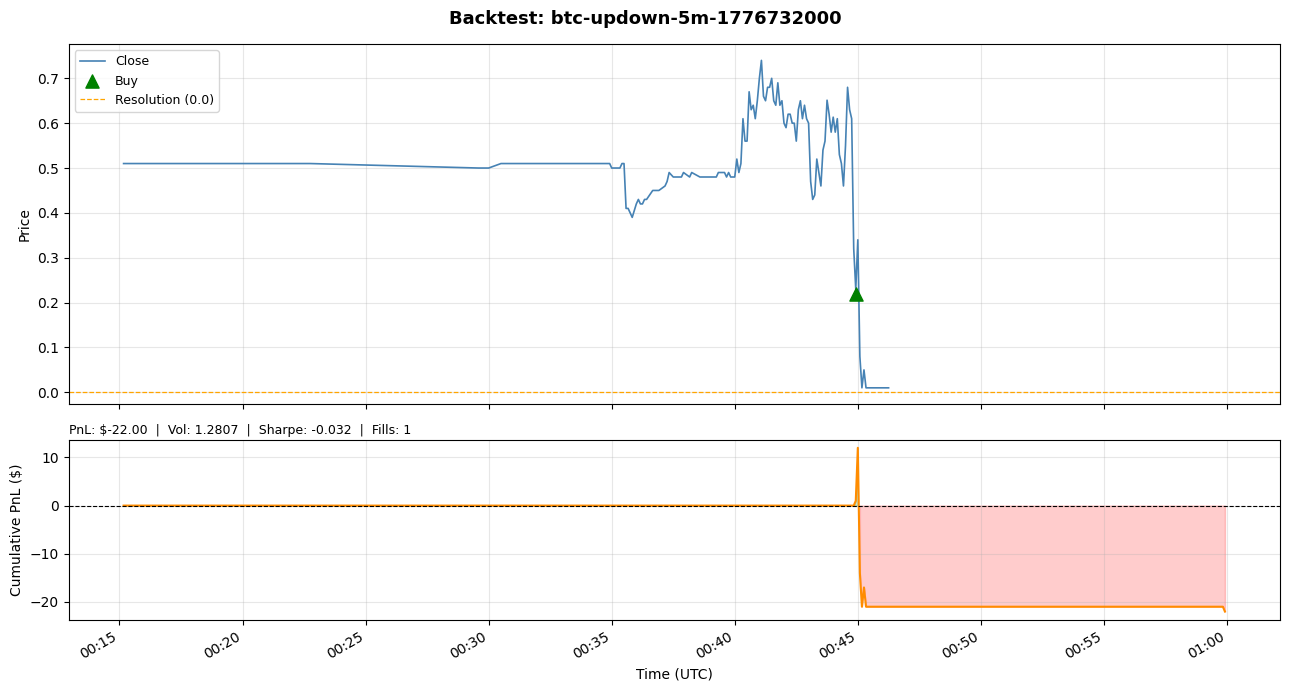

In [20]:
result.plot()

## 7. Threshold sweep

Grid search over `(buy_threshold, sell_threshold)` pairs to see which parameters
would have performed best on this market.

In [21]:
import itertools

rows = []
for buy, sell in itertools.product([0.25, 0.30, 0.35, 0.40], [0.60, 0.65, 0.70, 0.75]):
    if buy >= sell:
        continue

    class _T:
        def __init__(self, b, s): self.b, self.s = b, s
        def run(self, state):
            sym = next(iter(state.listings))
            bar = state.bars[sym]
            pos = state.position.get(sym, 0.0)
            orders = []
            if bar.trade_count == 0 or bar.close != bar.close:
                return {sym: orders}, ""
            if bar.close < self.b and pos <= 0:
                orders.append(Order(symbol=sym, price=1.0, quantity=TRADE_SIZE))
            elif bar.close > self.s and pos > 0:
                orders.append(Order(symbol=sym, price=0.0, quantity=-pos))
            return {sym: orders}, ""

    r = BacktestEngine(
        symbol=SLUG, listing=listing, bars=bars,
        resolution=RESOLUTION, trader=_T(buy, sell),
        fill_model=NextBarOpen(), initial_cash=1000.0,
    ).run()

    rows.append({"buy": buy, "sell": sell,
                 "pnl": round(r.total_pnl, 2),
                 "sharpe": round(r.sharpe, 3),
                 "fills": len(r.fills)})

sweep = pd.DataFrame(rows).sort_values("pnl", ascending=False)
sweep

,buy,sell,pnl,sharpe,fills
14,0.40,0.70,7.0,0.008,3
13,0.40,0.65,4.0,0.005,3
12,0.40,0.60,-6.0,-0.008,3
8,0.35,0.60,-22.0,-0.032,1
9,0.35,0.65,-22.0,-0.032,1
10,0.35,0.70,-22.0,-0.032,1
11,0.35,0.75,-22.0,-0.032,1
0,0.25,0.60,-26.0,-0.039,1
1,0.25,0.65,-26.0,-0.039,1
2,0.25,0.70,-26.0,-0.039,1
